DESCARGAR BIBLIOTECAS EN ENTORNO VIRTUAL

DESCARGAR BIBLIOTECAS EN ENTORNO VIRTUAL

In [126]:
#%pip install ipykernel
%pip install pandas matplotlib

Note: you may need to restart the kernel to use updated packages.


IMPORTAR BIBLIOTECAS

In [127]:
import pandas as pd
import matplotlib.pyplot as plt

GENERAR DATAFRAMES

In [128]:
nacimientos_madres = pd.read_csv("DATA/cantidad_de_nacimientos_edad_madre_por_anio_de_nacimiento_2012_2024.csv")
nacimientos_madres.info()

nacimientos_madres = nacimientos_madres[['anio', 'provincia_nombre', 'grupo_etario_madre', 'cantidad']]
nacimientos_madres.head()

<class 'pandas.DataFrame'>
RangeIndex: 2496 entries, 0 to 2495
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   provincia_nombre    2496 non-null   str    
 1   provincia_id        1976 non-null   float64
 2   grupo_etario_madre  2496 non-null   str    
 3   anio                2496 non-null   int64  
 4   cantidad            2496 non-null   int64  
dtypes: float64(1), int64(2), str(2)
memory usage: 97.6 KB


,anio,provincia_nombre,grupo_etario_madre,cantidad
0,2012,Buenos Aires,10-14,974
1,2013,Buenos Aires,10-14,992
2,2014,Buenos Aires,10-14,968
3,2015,Buenos Aires,10-14,848
4,2016,Buenos Aires,10-14,689


In [129]:
nacimientos = pd.read_csv("DATA/nacimientos_por_departamento_y_anio_2012_2024.csv")
nacimientos.info()

nacimientos = nacimientos[['anio', 'provincia_nombre', 'nacimientos']]
nacimientos.head()

<class 'pandas.DataFrame'>
RangeIndex: 6669 entries, 0 to 6668
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   anio                 6669 non-null   int64  
 1   provincia_nombre     6669 non-null   str    
 2   provincia_id         6669 non-null   int64  
 3   departamento_nombre  6669 non-null   str    
 4   departemento_id      6656 non-null   float64
 5   nacimientos          6669 non-null   int64  
dtypes: float64(1), int64(3), str(2)
memory usage: 312.7 KB


,anio,provincia_nombre,nacimientos
0,2012,Buenos Aires,575
1,2012,Buenos Aires,721
2,2012,Buenos Aires,221
3,2012,Buenos Aires,163
4,2012,Buenos Aires,128


In [130]:
poblacion_provincia=pd.read_csv('DATA/poblacion_identificada_provincia_agosto_2024.csv')


MODIFICAR Y GRAFICAR DATAFRAMES 

In [131]:
agrupado = nacimientos_madres.groupby(['grupo_etario_madre', 'anio'], as_index=False)['cantidad'].sum()
resultado = agrupado.loc[agrupado.groupby('grupo_etario_madre')['cantidad'].idxmax()]
print(resultado)

   grupo_etario_madre  anio  cantidad
1               10-14  2013      3593
15              15-19  2014    120983
28              20-24  2014    191246
41              25-29  2014    175412
54              30-34  2014    157940
68              35-39  2015     96157
84              40-44  2018     24982
98              45-49  2019      1799


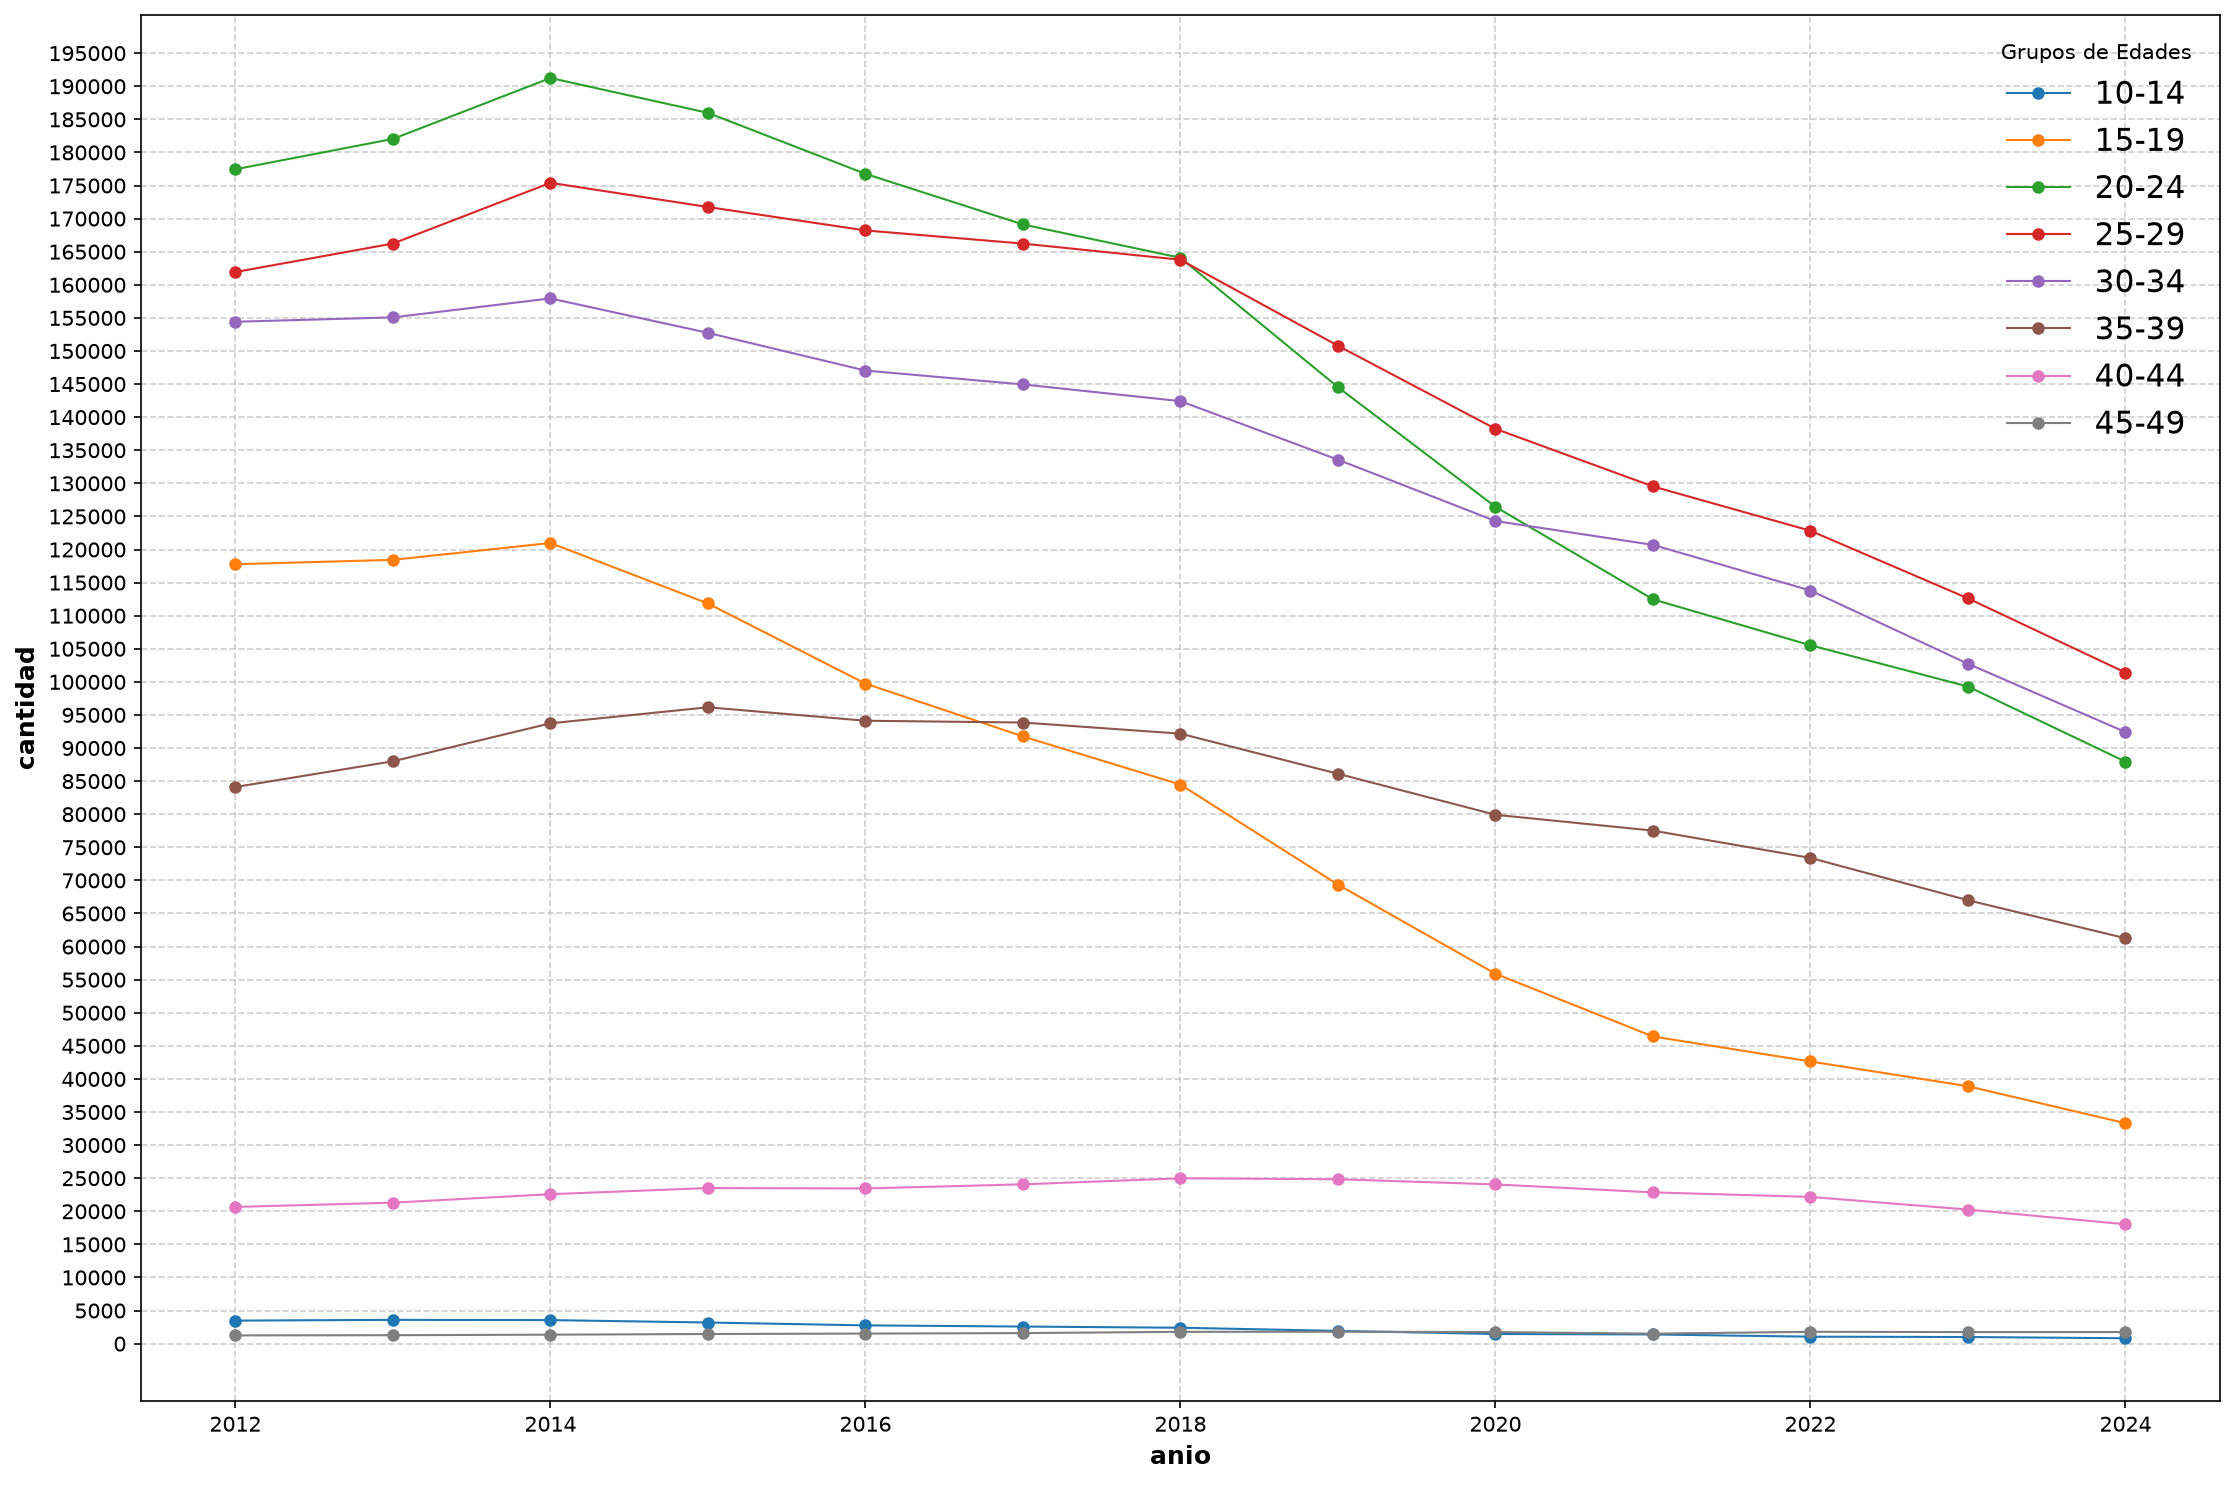

In [132]:
madres_grupo_edad_total = (nacimientos_madres.groupby(['anio','grupo_etario_madre'],as_index=False)['cantidad'].sum())
max_por_año= madres_grupo_edad_total.loc[madres_grupo_edad_total.groupby('grupo_etario_madre')['cantidad'].idxmax()].reset_index(drop=True)

plt.figure(figsize=(15,10),dpi=150)
for grupo, df_grupo in madres_grupo_edad_total.groupby('grupo_etario_madre'):
    plt.plot(df_grupo['anio'], df_grupo['cantidad'], label=grupo, marker='o',markersize=5, linewidth=1)

val_min = int(madres_grupo_edad_total['cantidad'].min())
val_max = int(madres_grupo_edad_total['cantidad'].max())
paso = 5000
plt.yticks(range(0, val_max + paso, paso))

plt.grid(True, linestyle='--', alpha=0.6)
plt.xlabel('anio',fontsize=12, fontweight='bold')
plt.ylabel('cantidad',fontsize=12, fontweight='bold')
plt.legend(title='Grupos de Edades', bbox_to_anchor=(1, 1), frameon=False, fontsize=15)
plt.tight_layout()
plt.show() 


<Axes: title={'center': 'Cantidad de madres'}, xlabel='Año'>

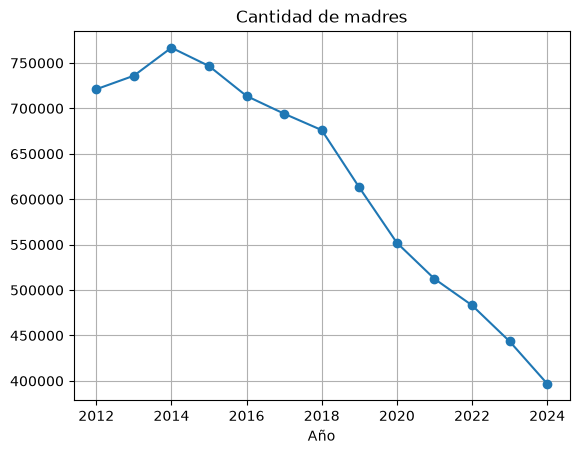

In [133]:
madres_total_año = nacimientos_madres.groupby('anio')['cantidad'].sum()
madres_total_año.plot(kind='line', grid=True, title='Cantidad de madres', xlabel='Año', marker='o')

<Axes: title={'center': 'Cantidad de nacimientos'}, xlabel='Año'>

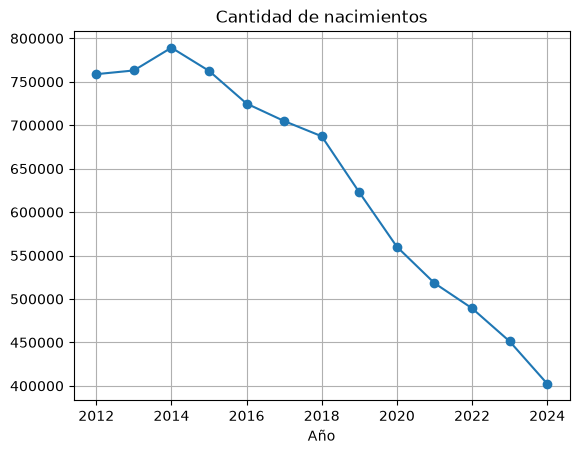

In [134]:
nacimientos_total_año = nacimientos.groupby('anio')['nacimientos'].sum()
nacimientos_total_año.plot(kind='line', grid=True, title='Cantidad de nacimientos', xlabel='Año', marker='o')

<Axes: ylabel='nombre_provincia'>

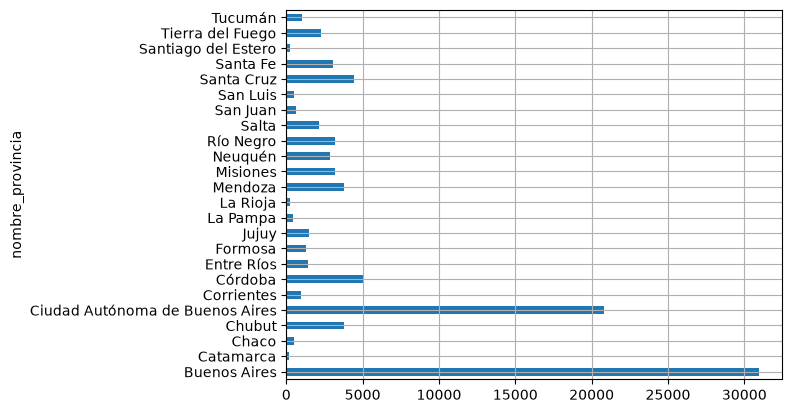

In [135]:
poblacion_provincia_m=poblacion_provincia[(poblacion_provincia['sexo'] == 'M') & (poblacion_provincia['nacionalidad'] == 'Argentina' ) & (poblacion_provincia['pais_nacimiento'] == 'Otro Pais')]

poblacion_provincia_m=poblacion_provincia_m.groupby('nombre_provincia')['cantidad'].sum()

poblacion_provincia_m.plot(kind='barh', grid=True)

<Axes: ylabel='nombre_provincia'>

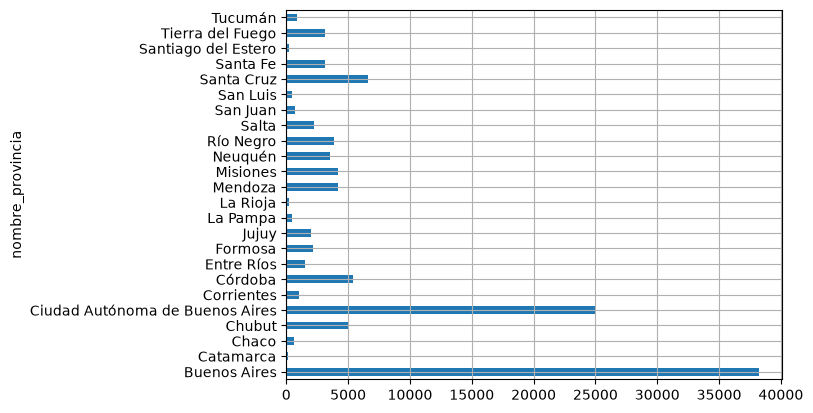

In [136]:
poblacion_provincia_f=poblacion_provincia[(poblacion_provincia['sexo'] == 'F' ) & (poblacion_provincia['nacionalidad'] == 'Argentina' ) & (poblacion_provincia['pais_nacimiento'] == 'Otro Pais')]

poblacion_provincia_f=poblacion_provincia_f.groupby('nombre_provincia')['cantidad'].sum()

poblacion_provincia_f.plot(kind='barh', grid=True)


<Axes: ylabel='edad_quinquenal'>

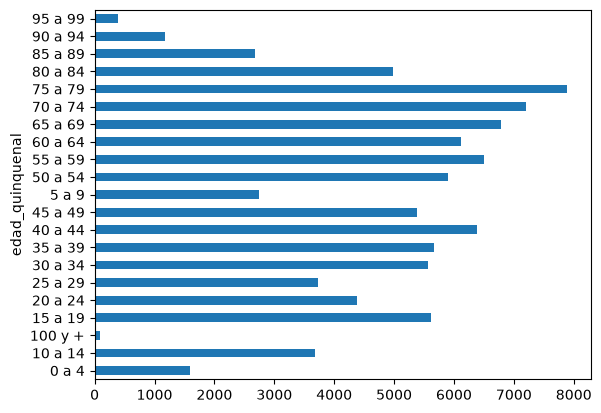

In [137]:
poblacion_provincia_m=poblacion_provincia[(poblacion_provincia['sexo'] == 'M') & (poblacion_provincia['nacionalidad'] == 'Argentina' ) & (poblacion_provincia['pais_nacimiento'] == 'Otro Pais') ]

poblacion_provincia_m=poblacion_provincia_m.groupby('edad_quinquenal')['cantidad'].sum()
poblacion_provincia_m.plot(kind='barh')


<Axes: ylabel='edad_quinquenal'>

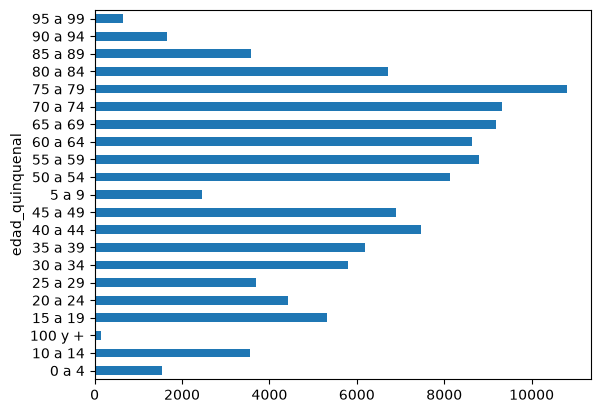

In [138]:
poblacion_provincia_f=poblacion_provincia[(poblacion_provincia['sexo'] == 'F') & (poblacion_provincia['nacionalidad'] == 'Argentina' ) & (poblacion_provincia['pais_nacimiento'] == 'Otro Pais') ]

poblacion_provincia_f=poblacion_provincia_f.groupby('edad_quinquenal')['cantidad'].sum()
poblacion_provincia_f.plot(kind='barh')

GENERAR NUEVOS DATOS

In [139]:
madres_total_año.to_csv("DATA_PROCESADA/madres_total_año.csv")

nacimientos_total_año.to_csv("DATA_PROCESADA/nacimientos_total_año.csv")

In [140]:
#%pip install ipykernel
#%pip install pandas matplotlib

IMPORTAR BIBLIOTECAS

In [141]:
import pandas as pd
import matplotlib.pyplot as plt

GENERAR DATAFRAMES

In [142]:
nacimientos_madres = pd.read_csv("DATA/cantidad_de_nacimientos_edad_madre_por_anio_de_nacimiento_2012_2024.csv")
nacimientos_madres.info()

nacimientos_madres = nacimientos_madres[['anio', 'provincia_nombre', 'grupo_etario_madre', 'cantidad']]
nacimientos_madres.head()

<class 'pandas.DataFrame'>
RangeIndex: 2496 entries, 0 to 2495
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   provincia_nombre    2496 non-null   str    
 1   provincia_id        1976 non-null   float64
 2   grupo_etario_madre  2496 non-null   str    
 3   anio                2496 non-null   int64  
 4   cantidad            2496 non-null   int64  
dtypes: float64(1), int64(2), str(2)
memory usage: 97.6 KB


,anio,provincia_nombre,grupo_etario_madre,cantidad
0,2012,Buenos Aires,10-14,974
1,2013,Buenos Aires,10-14,992
2,2014,Buenos Aires,10-14,968
3,2015,Buenos Aires,10-14,848
4,2016,Buenos Aires,10-14,689


In [143]:
nacimientos = pd.read_csv("DATA/nacimientos_por_departamento_y_anio_2012_2024.csv")
nacimientos.info()

nacimientos = nacimientos[['anio', 'provincia_nombre', 'nacimientos']]
nacimientos.head()

<class 'pandas.DataFrame'>
RangeIndex: 6669 entries, 0 to 6668
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   anio                 6669 non-null   int64  
 1   provincia_nombre     6669 non-null   str    
 2   provincia_id         6669 non-null   int64  
 3   departamento_nombre  6669 non-null   str    
 4   departemento_id      6656 non-null   float64
 5   nacimientos          6669 non-null   int64  
dtypes: float64(1), int64(3), str(2)
memory usage: 312.7 KB


,anio,provincia_nombre,nacimientos
0,2012,Buenos Aires,575
1,2012,Buenos Aires,721
2,2012,Buenos Aires,221
3,2012,Buenos Aires,163
4,2012,Buenos Aires,128


MODIFICAR Y GRAFICAR DATAFRAMES 

In [144]:
agrupado = nacimientos_madres.groupby(['grupo_etario_madre', 'anio'], as_index=False)['cantidad'].sum()
resultado = agrupado.loc[agrupado.groupby('grupo_etario_madre')['cantidad'].idxmax()]
print(resultado)

   grupo_etario_madre  anio  cantidad
1               10-14  2013      3593
15              15-19  2014    120983
28              20-24  2014    191246
41              25-29  2014    175412
54              30-34  2014    157940
68              35-39  2015     96157
84              40-44  2018     24982
98              45-49  2019      1799


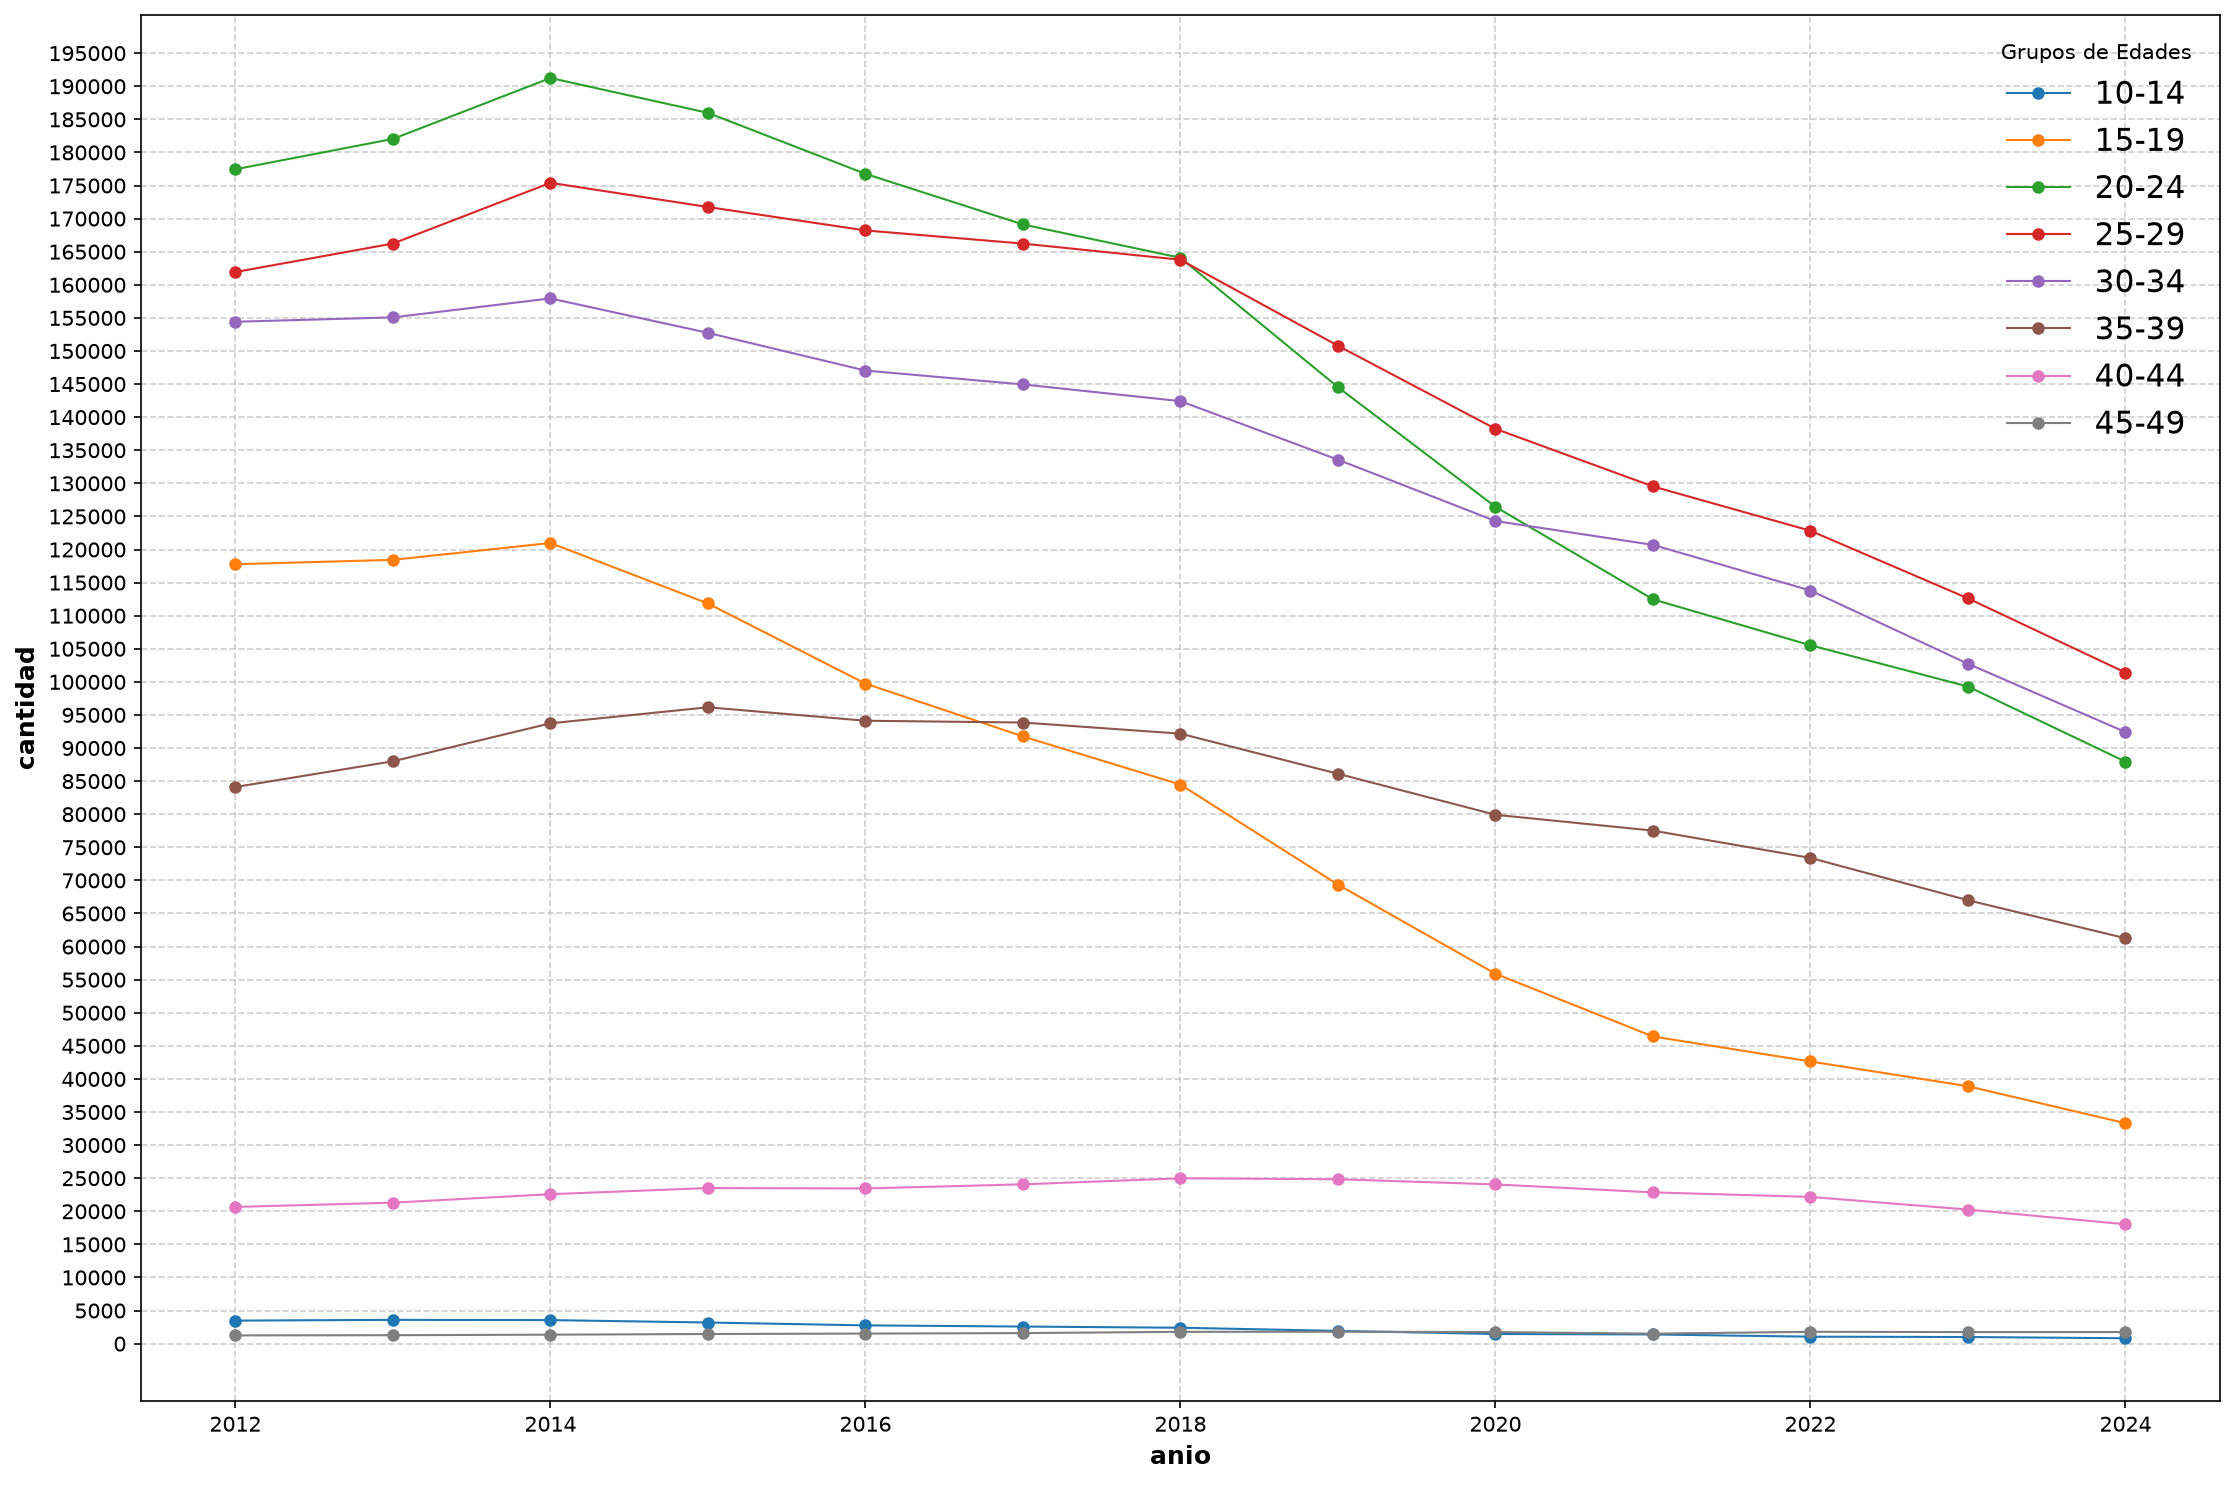

In [145]:
madres_grupo_edad_total = (nacimientos_madres.groupby(['anio','grupo_etario_madre'],as_index=False)['cantidad'].sum())
max_por_año= madres_grupo_edad_total.loc[madres_grupo_edad_total.groupby('grupo_etario_madre')['cantidad'].idxmax()].reset_index(drop=True)

plt.figure(figsize=(15,10),dpi=150)
for grupo, df_grupo in madres_grupo_edad_total.groupby('grupo_etario_madre'):
    plt.plot(df_grupo['anio'], df_grupo['cantidad'], label=grupo, marker='o',markersize=5, linewidth=1)

val_min = int(madres_grupo_edad_total['cantidad'].min())
val_max = int(madres_grupo_edad_total['cantidad'].max())
paso = 5000
plt.yticks(range(0, val_max + paso, paso))

plt.grid(True, linestyle='--', alpha=0.6)
plt.xlabel('anio',fontsize=12, fontweight='bold')
plt.ylabel('cantidad',fontsize=12, fontweight='bold')
plt.legend(title='Grupos de Edades', bbox_to_anchor=(1, 1), frameon=False, fontsize=15)
plt.tight_layout()
plt.show()


<Axes: title={'center': 'Cantidad de madres'}, xlabel='Año'>

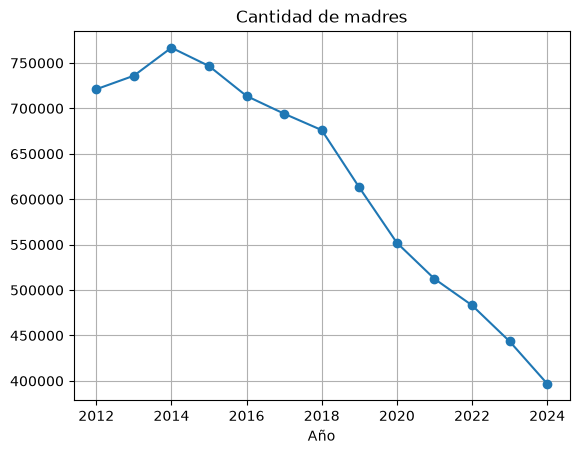

In [146]:
madres_total_año = nacimientos_madres.groupby('anio')['cantidad'].sum()
madres_total_año.plot(kind='line', grid=True, title='Cantidad de madres', xlabel='Año', marker='o')

<Axes: title={'center': 'Cantidad de nacimientos'}, xlabel='Año'>

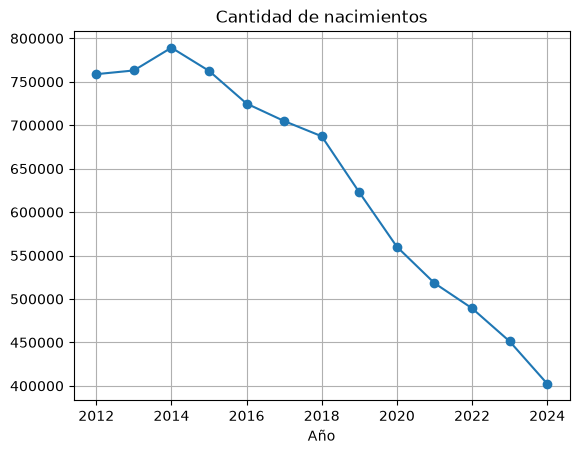

In [147]:
nacimientos_total_año = nacimientos.groupby('anio')['nacimientos'].sum()
nacimientos_total_año.plot(kind='line', grid=True, title='Cantidad de nacimientos', xlabel='Año', marker='o')

GENERAR NUEVOS DATOS

In [148]:
madres_total_año.to_csv("DATA_PROCESADA/madres_total_año.csv")

nacimientos_total_año.to_csv("DATA_PROCESADA/nacimientos_total_año.csv")